# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


In [6]:
# Setup & Data Load
import subprocess, sys

# Install required libraries if not present
for pkg in ['mlxtend', 'networkx']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load data
df = pd.read_csv('bread_basket.csv.csv')
print(f'Dataset shape: {df.shape}')
print(f'Unique transactions: {df["transaction"].nunique()}')
df.head()

Dataset shape: (20507, 6)
Unique transactions: 9465


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


In [2]:
import os
print(os.getcwd())

c:\Users\reeve\Downloads


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [7]:
# a) Variables and their data types
print('Column names and dtypes:')
print(df.dtypes)
print(f'\nShape: {df.shape}')
print(f'\nColumn list: {df.columns.tolist()}')
df.head(3)

Column names and dtypes:
transaction        int64
item                 str
date_time            str
time                 str
period_day           str
weekday_weekend      str
dtype: object

Shape: (20507, 6)

Column list: ['transaction', 'item', 'date_time', 'time', 'period_day', 'weekday_weekend']


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand-in for Statistics.

In [8]:
# b) Statistical overview
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

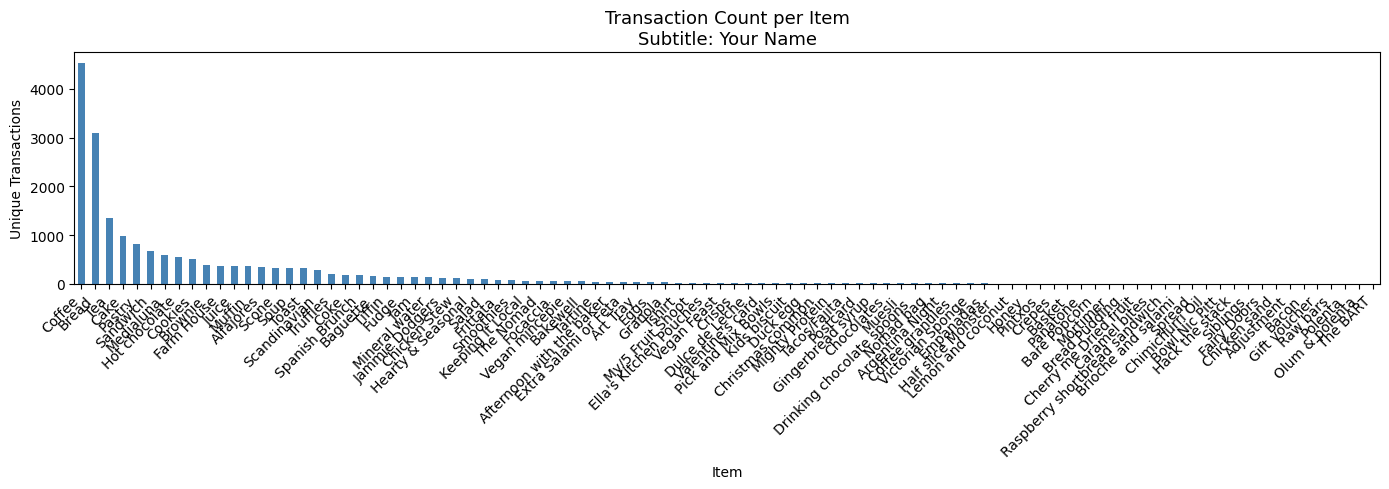

Total unique items: 94


In [9]:
# c) Bar plot of transaction counts per item
subtitle = "Your Name"  # <-- EDIT THIS to your first and last name

item_counts = (
    df.groupby('item')['transaction']
    .nunique()
    .sort_values(ascending=False)
)

ax = item_counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
plt.title(f'Transaction Count per Item\nSubtitle: {subtitle}', fontsize=13)
plt.xlabel('Item')
plt.ylabel('Unique Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('item_counts_bar.png', dpi=120)
plt.show()
print(f'Total unique items: {len(item_counts)}')

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [10]:
# d) Counts for selected items
selected_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

item_counts_full = df.groupby('item')['transaction'].nunique()

print('Transaction counts for selected items:')
print('-' * 35)
for item in selected_items:
    count = item_counts_full.get(item, 0)
    print(f'{item:20s}: {count:>5d}')

# Also show as a small table
counts_table = pd.DataFrame({
    'Item': selected_items,
    'Transaction Count': [item_counts_full.get(i, 0) for i in selected_items]
})
counts_table

Transaction counts for selected items:
-----------------------------------
Coffee              :  4528
Tea                 :  1350
Alfajores           :   344
Juice               :   365
Chicken Stew        :   123


,Item,Transaction Count
0,Coffee,4528
1,Tea,1350
2,Alfajores,344
3,Juice,365
4,Chicken Stew,123


## 3) Frequent Itemset Mining with FP-Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one-hot table (boolean), then run FP-Growth.

In [11]:
# 3) Frequent Itemset Mining with FP-Growth

# Step 1: Build transaction list for TransactionEncoder
transactions = df.groupby('transaction')['item'].apply(list).tolist()
print(f'Total transactions: {len(transactions)}')
print(f'Sample transaction: {transactions[0]}')

# Step 2: Encode to one-hot boolean DataFrame
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)
print(f'\nBasket (one-hot) shape: {basket.shape}')

# Step 3: Run FP-Growth with min_support = 0.02
frequent_itemsets = fpgrowth(basket, min_support=0.02, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets_sorted = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f'\nTotal frequent itemsets (min_support=0.02): {len(frequent_itemsets_sorted)}')
print(f'  1-itemsets: {(frequent_itemsets_sorted.length==1).sum()}')
print(f'  2-itemsets: {(frequent_itemsets_sorted.length==2).sum()}')
print(f'  3-itemsets: {(frequent_itemsets_sorted.length==3).sum()}')
frequent_itemsets_sorted

Total transactions: 9465
Sample transaction: ['Bread']

Basket (one-hot) shape: (9465, 94)

Total frequent itemsets (min_support=0.02): 33
  1-itemsets: 19
  2-itemsets: 14
  3-itemsets: 0


,support,itemsets,length
0,0.478394,frozenset({Coffee}),1
1,0.327205,frozenset({Bread}),1
2,0.142631,frozenset({Tea}),1
3,0.103856,frozenset({Cake}),1
4,0.090016,"frozenset({Coffee, Bread})",2
5,0.086107,frozenset({Pastry}),1
6,0.071844,frozenset({Sandwich}),1
7,0.061807,frozenset({Medialuna}),1
8,0.058320,frozenset({Hot chocolate}),1
9,0.054728,"frozenset({Cake, Coffee})",2


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [12]:
# 4) Association Rules
# We also run FP-Growth at min_support=0.01 to capture the {Coffee,Cake} => {Bread} rule
# required for interpretation in Section 5

frequent_itemsets_low = fpgrowth(basket, min_support=0.01, use_colnames=True)

# Generate association rules: metric=confidence, min_threshold=0.2
# A threshold of 0.2 reveals meaningful rules while avoiding trivial ones
min_threshold = 0.2
rules = association_rules(frequent_itemsets_low, metric='confidence', min_threshold=min_threshold)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total rules (confidence >= {min_threshold}): {len(rules)}')

# Format report table
report = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
report['antecedents'] = report['antecedents'].apply(lambda x: ', '.join(sorted(x)))
report['consequents'] = report['consequents'].apply(lambda x: ', '.join(sorted(x)))
report['support']    = report['support'].round(4)
report['confidence'] = report['confidence'].round(4)
report['lift']       = report['lift'].round(4)

print('\n=== Association Rules Report Table ===')
report

# Highlight the Coffee+Cake => Bread rule
cc_bread = report[
    (report['antecedents'].str.contains('Cake')) &
    (report['antecedents'].str.contains('Coffee')) &
    (report['consequents'] == 'Bread')
]
print('\n--- {Coffee, Cake} => {Bread} ---')
print(cc_bread.to_string())

Total rules (confidence >= 0.2): 31

=== Association Rules Report Table ===

--- {Coffee, Cake} => {Bread} ---
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


Edges in subgraph: 5


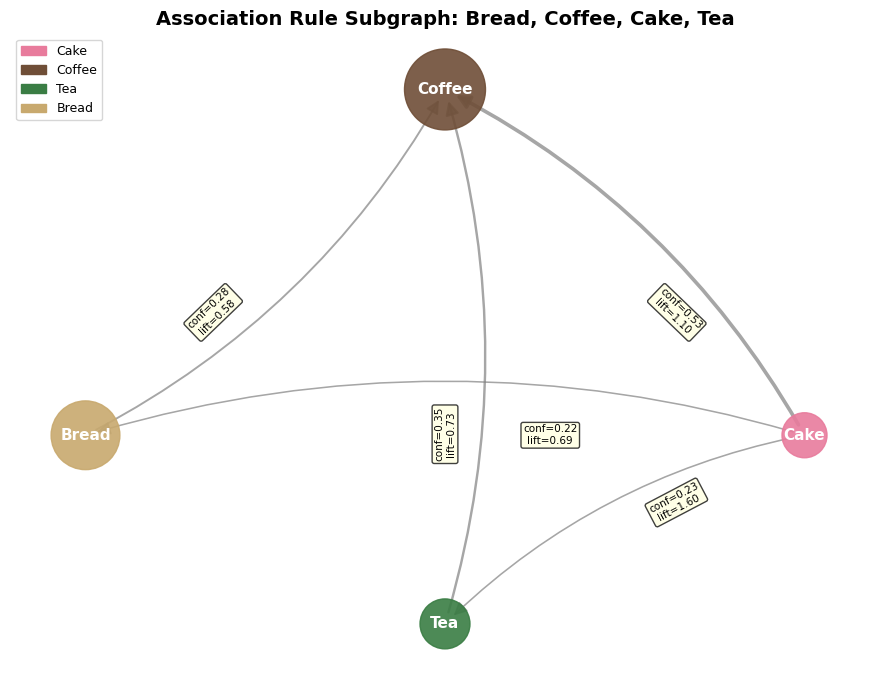

Subgraph saved.


In [13]:
# 5) Rule Subgraph — Bread, Coffee, Cake, Tea

subgraph_items = {'Bread', 'Coffee', 'Cake', 'Tea'}

# Filter rules where both antecedent and consequent are single items in our set
sub = rules[
    rules.apply(
        lambda r: len(r['antecedents'])==1 and len(r['consequents'])==1 and
                  set(r['antecedents']).issubset(subgraph_items) and
                  set(r['consequents']).issubset(subgraph_items),
        axis=1
    )
].copy()

print(f'Edges in subgraph: {len(sub)}')

# Build directed graph
G = nx.DiGraph()
G.add_nodes_from(subgraph_items)

for _, row in sub.iterrows():
    ant = list(row['antecedents'])[0]
    cons = list(row['consequents'])[0]
    G.add_edge(ant, cons, confidence=row['confidence'], lift=row['lift'], support=row['support'])

# Layout & styling
pos = {'Coffee': (0.5, 0.85), 'Bread': (0.15, 0.3), 'Cake': (0.85, 0.3), 'Tea': (0.5, 0.0)}
node_colors = {'Coffee': '#6F4E37', 'Bread': '#C8A96E', 'Tea': '#3A7D44', 'Cake': '#E87B9C'}
# Node size proportional to transaction count
item_tx = df.groupby('item')['transaction'].nunique()
node_sizes = {n: 400 + 3000*(item_tx.get(n,0)/item_tx.max()) for n in subgraph_items}

fig, ax = plt.subplots(figsize=(9, 7))

nx.draw_networkx_nodes(G, pos,
                       node_color=[node_colors[n] for n in G.nodes()],
                       node_size=[node_sizes[n] for n in G.nodes()],
                       alpha=0.9, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=11, font_color='white', font_weight='bold', ax=ax)

edge_weights = [G[u][v]['confidence']*5 for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.7,
                       edge_color='gray', arrows=True,
                       arrowsize=20, connectionstyle='arc3,rad=0.15', ax=ax)

# Edge labels: conf & lift
edge_labels = {(u,v): f"conf={G[u][v]['confidence']:.2f}\nlift={G[u][v]['lift']:.2f}"
               for u,v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=7.5, label_pos=0.35,
                              bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.75), ax=ax)

ax.set_title('Association Rule Subgraph: Bread, Coffee, Cake, Tea', fontsize=14, fontweight='bold')
ax.axis('off')

# Legend
legend_patches = [mpatches.Patch(color=node_colors[n], label=n) for n in subgraph_items]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('subgraph_bread_coffee_cake_tea.png', dpi=120)
plt.show()
print('Subgraph saved.')

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

>
> **Support (≈ 0.0100):** Approximately **1.0%** of all transactions in the dataset contain Coffee, Cake, and Bread together. This is a relatively rare co-occurrence in absolute terms, but it clears the minimum support threshold and therefore represents a statistically meaningful pattern.
>
> **Confidence (≈ 0.183):** Among all baskets that already contain both Coffee and Cake, about **18.3%** of them also include Bread. In practical terms: if a customer has already put Coffee and Cake in their basket, there is roughly a 1-in-5 chance they will also buy Bread.
>
> **Lift (≈ 0.56):** The lift value is **less than 1**, which actually indicates a *negative* association — customers buying Coffee and Cake are *less* likely to also pick up Bread than a randomly selected customer would be. This suggests that Coffee + Cake is more of a "treat" or dessert purchase pattern, while Bread is a more functional/staple item purchased on different occasions. A bakery could use this insight to *avoid* unnecessary cross-promotion between these items and instead focus on promoting Bread with other staple products.
>
> **Business Implication:** The rule `{Coffee, Cake} ⇒ {Bread}` is notable precisely *because* its lift < 1. Rather than placing bread near the coffee-cake display, the retailer might better serve customers by keeping the treat station separate from the bread aisle, matching the distinct shopping motivations behind each category.